# 00 — Exploratory Data Analysis: browse the trimodal datasets

A no-training, no-GPU notebook to **browse the sketch–photo–text data** before
modeling. It resolves whichever dataset the config selects (real Sketchy tree →
Hugging Face mirror `justpers/sketchy` → procedural mock; see `paper.md` §3 and
A2), then shows:

1. dataset composition — triples, instances, classes, **`source` split**
   (real vs synthetic), and the **sketches-per-instance** histogram that decides
   whether per-instance κ is estimable (paper.md §3.3);
2. a **class grid** — one photo per class;
3. **multi-sketch spreads** — several human sketches of the *same* photo, which
   is the visual intuition behind κ_sketch (abstraction variance);
4. **caption inspection** — the (pseudo-)text per instance and the class label
   parsed from it.

**CLI:** `python run.py EDA` (see `run.py`). Nothing here trains; it just reads
`data/`.

In [1]:
%matplotlib inline
# ============================ CONFIG ============================
# Edit here, or override headlessly:   python run.py 00 --set steps=200 dataset=mock
# All keys + defaults live in lib/config.py; TRIMODAL_* env vars override them.
import sys, pathlib
_p = pathlib.Path.cwd()
if not (_p / "lib").exists() and (_p / "trimodal-loss" / "lib").exists():
    _p = _p / "trimodal-loss"          # allow launching jupyter from the repo root
sys.path.insert(0, str(_p))

from lib.config import get_config
from lib.run_utils import new_run_dir

NOTEBOOK = "00_EDA"
CONFIG = get_config()                  # e.g. get_config(dataset="mock", backbone="toy")
RUN_DIR = new_run_dir(NOTEBOOK)        # every run gets its own results folder
print("run dir:", RUN_DIR)
for k, v in sorted(CONFIG.items()):
    print(f"  {k:26s} {v}")

run dir: C:\Users\soura\Code\2026\trimodal-loss\runs\00_EDA\20260709-191454
  backbone                   clip
  batch_size                 24
  clip_model                 ViT-B-32
  clip_pretrained            openai
  data_root                  C:\Users\soura\Code\2026\trimodal-loss\data
  dataset                    sketchy
  device                     auto
  eval_max_queries           400
  image_size                 224
  kappa_init                 100.0
  kappa_lr                   1.0
  karcher_exact              True
  karcher_iters              8
  lambda_frechet             1.0
  lambda_triangle            1.0
  lambda_vmf                 0.05
  lora_alpha                 16.0
  lora_rank                  8
  lr                         0.001
  max_instances_per_class    12
  num_classes                8
  recall_ks                  (1, 5, 10)
  seed                       42
  sketches_per_photo         3
  steps                      60
  temperature                0.07
  triplet

In [2]:
# Resolve the dataset (download-or-mock) WITHOUT building a model
from lib.data import prepare_triples, split_triples, summarize_triples
import json

triples, ds_name = prepare_triples(CONFIG)
train_t, test_t = split_triples(triples)
summary = summarize_triples(triples)
print(f"dataset resolved to: {ds_name}\n")
print(json.dumps({k: v for k, v in summary.items()
                  if k not in ("per_class", "instances_per_class")}, indent=2))
print("\ntrain/test split:", len(train_t), "/", len(test_t))

[data] using Sketchy HF mirror (justpers/sketchy) at C:\Users\soura\Code\2026\trimodal-loss\data\sketchy_hf — real human sketches, GENERATED captions (pseudo-text)
dataset resolved to: sketchy-hf

{
  "n_triples": 288,
  "n_instances": 96,
  "n_classes": 8,
  "per_source": {
    "real": 288
  },
  "sketches_per_instance_hist": {
    "3": 96
  }
}

train/test split: 183 / 105


## 1. Composition — per-class counts and the source split

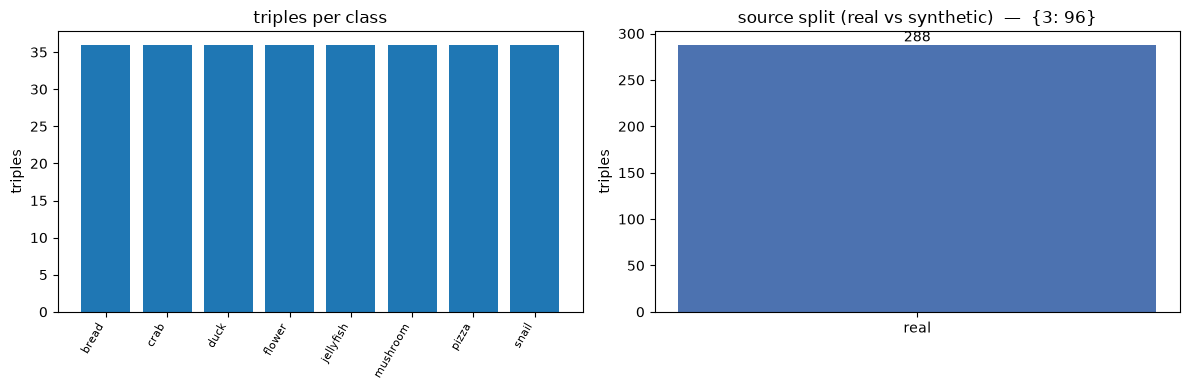

sketches-per-instance histogram: {3: 96}
-> per-instance κ is well-posed only where an instance has >=3 sketches (paper.md §3.3)


In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
pc = summary["per_class"]
ax[0].bar(range(len(pc)), list(pc.values()))
ax[0].set_xticks(range(len(pc))); ax[0].set_xticklabels(list(pc), rotation=60, ha="right", fontsize=8)
ax[0].set(title="triples per class", ylabel="triples")

src = summary["per_source"]
ax[1].bar(list(src), list(src.values()), color=["#4c72b0", "#dd8452"])
ax[1].set(title=f"source split (real vs synthetic)  —  {summary['sketches_per_instance_hist']}",
          ylabel="triples")
for i, (k, v) in enumerate(src.items()):
    ax[1].text(i, v, str(v), ha="center", va="bottom")
fig.tight_layout(); fig.savefig(RUN_DIR / "eda_composition.png", dpi=110); plt.show()

print("sketches-per-instance histogram:", summary["sketches_per_instance_hist"])
print("-> per-instance κ is well-posed only where an instance has >=3 sketches (paper.md §3.3)")

## 2. Class grid — one representative photo per class

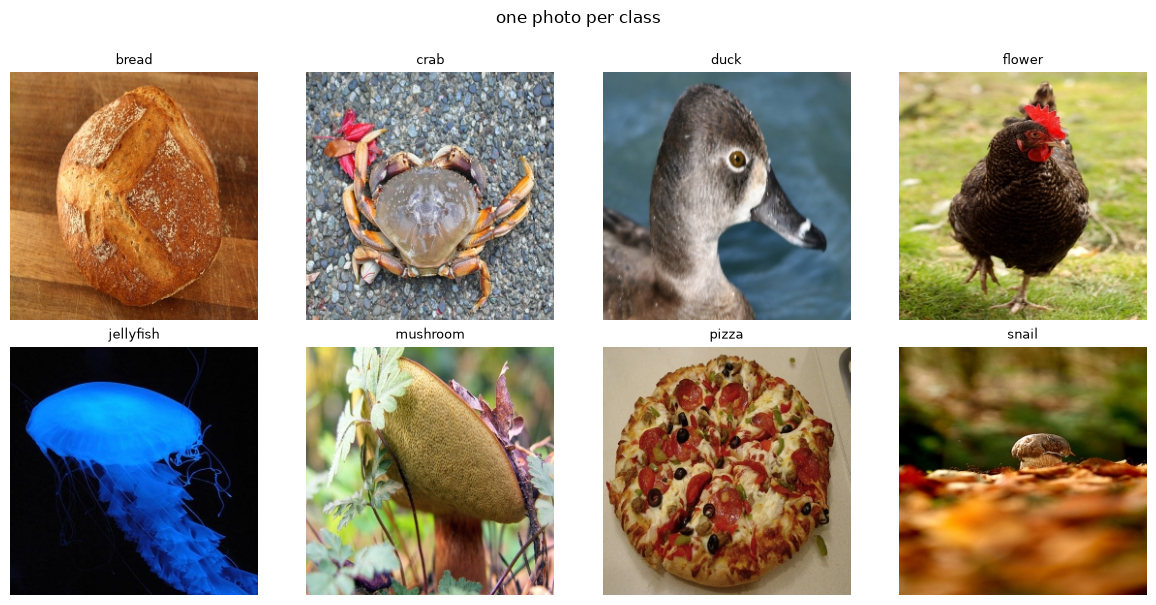

In [4]:
from PIL import Image

by_class = {}
for t in triples:
    by_class.setdefault(t.class_name, t)
classes = list(by_class)
cols = 4; rows = (len(classes) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
for ax, cls in zip(axes.flat, classes):
    ax.imshow(Image.open(by_class[cls].photo_path)); ax.set_title(cls, fontsize=9); ax.axis("off")
for ax in axes.flat[len(classes):]:
    ax.axis("off")
fig.suptitle("one photo per class", y=1.0); fig.tight_layout()
fig.savefig(RUN_DIR / "eda_class_grid.png", dpi=110); plt.show()

## 3. Multi-sketch spreads — abstraction variance within one instance

The visual intuition for the vMF framing: several people sketch the *same* photo
differently. Wider spread ⇒ lower κ_sketch. We pick instances that have the most
sketches and show the photo alongside all its sketches.

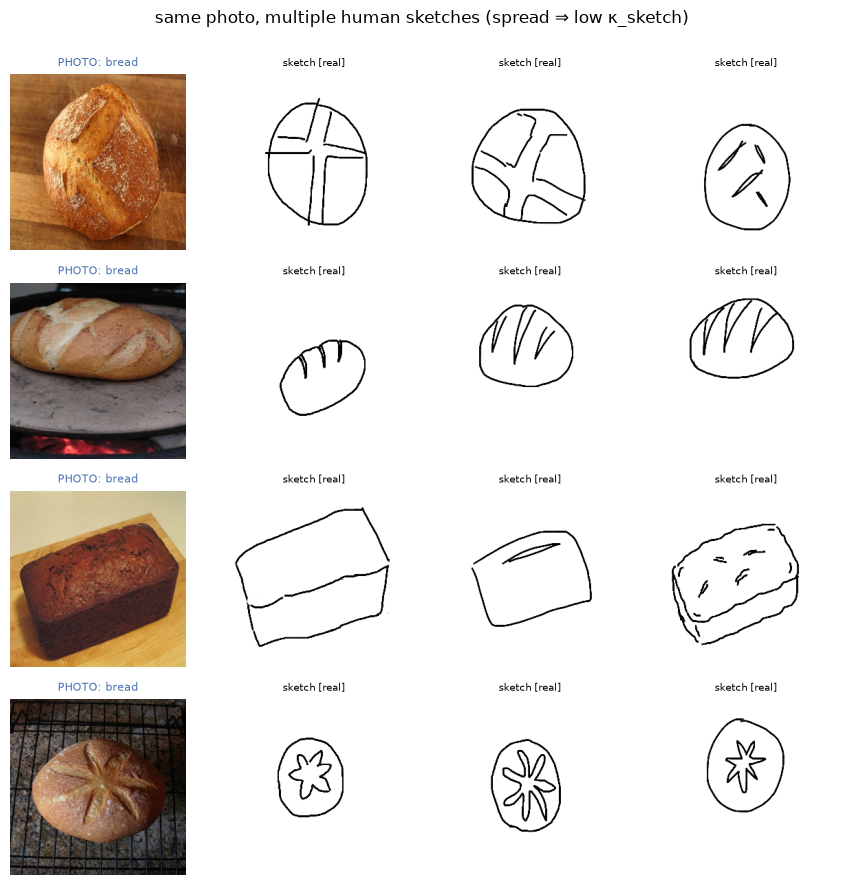

In [5]:
from collections import defaultdict
from PIL import Image

groups = defaultdict(list)
for t in triples:
    groups[t.instance_id].append(t)
multi = sorted(groups.values(), key=lambda g: -len(g))[:4]   # 4 most-sketched instances
maxk = max(len(g) for g in multi)
fig, axes = plt.subplots(len(multi), maxk + 1, figsize=(2.2 * (maxk + 1), 2.2 * len(multi)))
if len(multi) == 1:
    axes = axes.reshape(1, -1)
for r, g in enumerate(multi):
    axes[r, 0].imshow(Image.open(g[0].photo_path))
    axes[r, 0].set_title(f"PHOTO: {g[0].class_name}", fontsize=8, color="#4c72b0"); axes[r, 0].axis("off")
    for c in range(1, maxk + 1):
        axes[r, c].axis("off")
        if c - 1 < len(g):
            axes[r, c].imshow(Image.open(g[c - 1].sketch_path))
            axes[r, c].set_title(f"sketch [{g[c-1].source}]", fontsize=7)
fig.suptitle("same photo, multiple human sketches (spread ⇒ low κ_sketch)", y=1.0)
fig.tight_layout(); fig.savefig(RUN_DIR / "eda_multisketch.png", dpi=110); plt.show()

## 4. Captions & parsed class labels (pseudo-text — paper.md A1)

In [6]:
seen = set()
print(f"{'class':16s}  caption (pseudo-text)")
print("-" * 80)
for t in triples:
    if t.class_name not in seen:
        seen.add(t.class_name)
        print(f"{t.class_name:16s}  {t.caption[:60]}")
print("\nNOTE: on the HF mirror these captions are GENERATED (BLIP-style) and the class")
print("label is parsed from them by a heuristic; on real Sketchy there are no captions at")
print("all and text is a class prompt. Either way text on Sketchy is pseudo-text (A1).")

class             caption (pseudo-text)
--------------------------------------------------------------------------------
bread             a close up of a loaf of bread on a wooden table
crab              a close up of a crab on the ground with leaves
duck              there is a duck that is swimming in the water
flower            araffe standing on the grass in a field with a red flower
jellyfish         jellyfish in the dark with a blue glow on its face
mushroom          there is a mushroom that is growing out of the ground
pizza             there is a pizza with pepperoni, olives, and cheese on it
snail             there is a snail that is sitting on the ground in the leaves

NOTE: on the HF mirror these captions are GENERATED (BLIP-style) and the class
label is parsed from them by a heuristic; on real Sketchy there are no captions at
all and text is a class prompt. Either way text on Sketchy is pseudo-text (A1).
